# Week 6 — Out-of-sample backtest of the QAOA portfolio

`00001111` (HSBA, AZN, SHEL, ULVR) is the exact ground state of the cardinality-constrained mean-variance QUBO — so QAOA didn't find a *near*-optimal portfolio, it found the classical optimum under the 4-asset constraint. The only question left is the one a FinTech reader asks: **does that optimum hold up on data it was never fitted to?**

All weights are fixed at the train/test boundary and held through the test window (buy-and-hold), so this is genuine out-of-sample behaviour. Benchmarks: naive 1/N, and long-only min-variance and max-Sharpe over all eight assets.

## Section 0 — Setup

In [7]:
import sys, os
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))      # make src/ importable from notebooks/
import numpy as np, pandas as pd
from src import backtest as bt

## Section 1 — Config
Set `TRAIN_END` to your QUBO's data cutoff. Everything after it is out-of-sample.

In [8]:
TICKERS   = ['HSBA.L','AZN.L','SHEL.L','ULVR.L','RIO.L','BT-A.L','VOD.L','DGE.L']
START     = '2022-06-01'      # price history start (must cover train + test)
TRAIN_END = '2024-12-31'      # <-- align to the data window your QUBO was built on
END       = '2025-12-31'      # test window end (or None for latest available)
SELECTED_BITSTRING = '00001111'   # QAOA / QUBO ground state -> HSBA, AZN, SHEL, ULVR
RF_ANNUAL = 0.045             # ~UK risk-free for Sharpe; set 0.0 to ignore

## Section 2 — Load prices (yfinance)
Run this in `diarka-q` (it has yfinance + network).

In [3]:
prices = bt.load_prices(TICKERS, START, END)
print("prices:", prices.shape, "|", prices.index.min().date(), "->", prices.index.max().date())
prices.tail(3)

prices: (904, 8) | 2022-06-01 -> 2025-12-30


Ticker,HSBA.L,AZN.L,SHEL.L,ULVR.L,RIO.L,BT-A.L,VOD.L,DGE.L
Date,,,,,,,,
2025-12-24,1175.004761,13672.596680,2697.419434,4837.174805,5980.404297,184.775513,97.260002,1589.283936
2025-12-29,1165.607910,13746.588867,2705.417725,4859.171387,5948.413086,182.899994,97.500000,1589.283936
2025-12-30,1175.204590,13748.588867,2730.912109,4855.171875,6024.392578,183.699997,98.540001,1602.282104


## Section 3 — Backtest

In [4]:
res = bt.run_backtest(prices, train_end=TRAIN_END,
                      selected_bitstring=SELECTED_BITSTRING, rf_annual=RF_ANNUAL)
names = [k for k in res if not k.startswith('_')]
print(f"Out-of-sample  ({TRAIN_END} -> {prices.index.max().date()})\n")
print(f"{'portfolio':34s} {'cum%':>7} {'ann%':>7} {'vol%':>7} {'Sharpe':>7} {'maxDD%':>7}")
for nm in names:
    m = res[nm]
    print(f"{nm:34s} {100*m['cum_return']:7.2f} {100*m['ann_return']:7.2f} "
          f"{100*m['ann_vol']:7.2f} {m['sharpe']:7.2f} {100*m['max_drawdown']:7.2f}")

/Users/hp/Documents/diarka-qaoa-portfolio/src/backtest.py:26: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return prices.pct_change().dropna(how="any")


Out-of-sample  (2024-12-31 -> 2025-12-30)

portfolio                             cum%    ann%    vol%  Sharpe  maxDD%
QAOA / QUBO optimum (4 assets)       23.14   23.14   14.19    1.31  -14.55
Naive 1/N (8 assets)                 18.02   18.02   12.85    1.05  -11.98
Min-variance (8 assets)               9.00    9.00   12.70    0.35   -9.40
Max-Sharpe (8 assets)                28.94   28.94   16.15    1.51  -15.42


## Section 4 — Cumulative-return figure

saved -> /Users/hp/Documents/diarka-qaoa-portfolio/figures/week6_backtest.png


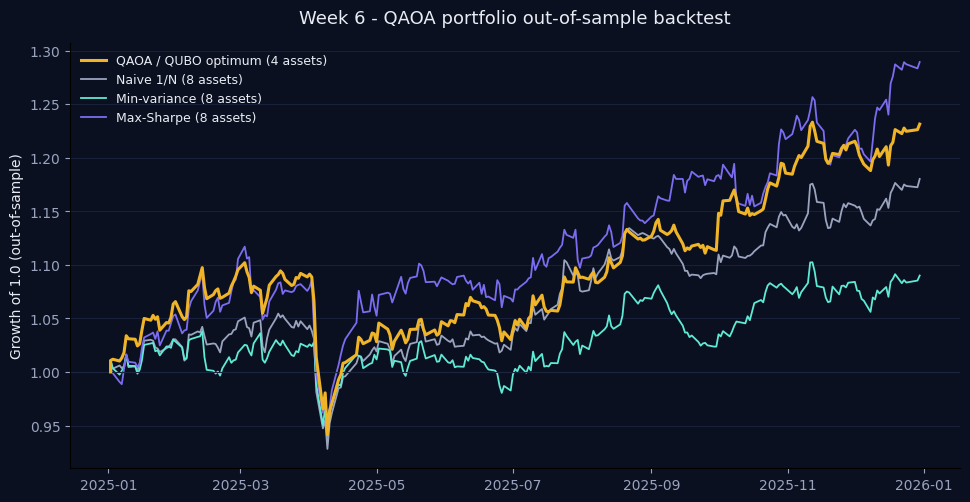

In [5]:
import matplotlib.pyplot as plt
palette = ['#f0b429', '#9AA4BF', '#5eead4', '#7c6cf0']
plt.rcParams.update({'font.family':'DejaVu Sans','figure.facecolor':'#0B1020','axes.facecolor':'#0B1020',
                     'text.color':'#E8ECF4','axes.labelcolor':'#E8ECF4','xtick.color':'#9AA4BF','ytick.color':'#9AA4BF'})
fig, ax = plt.subplots(figsize=(10,5.6)); fig.subplots_adjust(left=0.08,right=0.97,top=0.88,bottom=0.12)
idx = res['_test_index']
for nm, col in zip(names, palette):
    eq = np.concatenate([[1.0], res[nm]['equity']])
    ax.plot([idx[0]]+list(idx), eq, label=nm, color=col,
            lw=2.2 if nm==names[0] else 1.3, zorder=3 if nm==names[0] else 2)
ax.axhline(1.0, color='#1c2540', lw=0.8)
ax.set_ylabel("Growth of 1.0 (out-of-sample)")
ax.set_title("Week 6 - QAOA portfolio out-of-sample backtest", fontsize=13, pad=14)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.grid(axis='y', color='#1c2540', lw=0.6, zorder=0)
for s in ['top','right']: ax.spines[s].set_visible(False)
_figdir = os.path.join(os.path.abspath('..'),'figures'); os.makedirs(_figdir, exist_ok=True)
plt.savefig(os.path.join(_figdir,'week6_backtest.png'), dpi=200, facecolor='#0B1020', bbox_inches='tight')
print("saved ->", os.path.join(_figdir,'week6_backtest.png'))

## Section 5 — Portfolio weights

In [6]:
pd.DataFrame({nm: res[nm]['weights'] for nm in names}, index=TICKERS).round(3)

,QAOA / QUBO optimum (4 assets),Naive 1/N (8 assets),Min-variance (8 assets),Max-Sharpe (8 assets)
HSBA.L,0.25,0.125,0.055,0.603
AZN.L,0.25,0.125,0.096,0.000
SHEL.L,0.25,0.125,0.129,0.000
ULVR.L,0.25,0.125,0.406,0.397
RIO.L,0.00,0.125,0.081,0.000
BT-A.L,0.00,0.125,0.038,0.000
VOD.L,0.00,0.125,0.085,0.000
DGE.L,0.00,0.125,0.110,0.000


## Reading the result

- **QAOA vs Naive 1/N** — the headline. If the constrained 4-asset portfolio beats equal-weight on Sharpe and drawdown, concentration into the QUBO-optimal names paid off out-of-sample.
- **QAOA vs Min-variance / Max-Sharpe** — the honest test. Min-variance should show the lowest volatility and drawdown; max-Sharpe reaches for return. The QAOA portfolio is *constrained* (exactly 4 names, equal weight), so it won't dominate every metric — the story is whether it stays competitive while being far simpler to hold.
- **The robustness angle for FinTech** — full-covariance optimisers overfit in-sample estimates and often disappoint out-of-sample; a sparse, equal-weight selection is more robust. If QAOA's out-of-sample Sharpe is close to or above the unconstrained optimisers, that *is* the advisory story: the quantum-found portfolio is both optimal under the constraint and resilient.